In [1]:
import sys
sys.path.append("..")

from src.torch.pre_processing.graph_batching import batch_full_events_to_graphs, full_event_to_graphs
from src.plotting.feature_plotting import plot_graph
import matplotlib.pyplot as plt
import numpy as np
import torch

DATA_DIR = "../mu3e_trigger_data"
MODEL_DIR= "../models"
PLOTS_DIR = "../plots"
SIGNAL_PIXEL_FILE = f"{DATA_DIR}/sig_with_layer_pixel_spacetime.npy"
BACKGROUND_PIXEL_FILE = f"{DATA_DIR}/bg_with_layer_pixel_spacetime.npy"
SIGNAL_MPPC_FILE = f"{DATA_DIR}/sig_with_layer_mppc_spacetime.npy"
BACKGROUND_MPPC_FILE = f"{DATA_DIR}/bg_with_layer_mppc_spacetime.npy"
SIGNAL_ONLY_PIXEL_FILE = f"{DATA_DIR}/sig_only_with_layer_pixel_spacetime.npy"
SIGNAL_ONLY_MPPC_FILE = f"{DATA_DIR}/sig_only_with_layer_mppc_spacetime.npy"


bg_pixel_spacetime = np.load(BACKGROUND_PIXEL_FILE)
bg_mppc_spacetime = np.load(BACKGROUND_MPPC_FILE)
sig_pixel_spacetime = np.load(SIGNAL_PIXEL_FILE)
sig_mppc_spacetime = np.load(SIGNAL_MPPC_FILE)
sig_only_pixel_spacetime = np.load(SIGNAL_ONLY_PIXEL_FILE)
sig_only_mppc_spacetime = np.load(SIGNAL_ONLY_MPPC_FILE)


Event has 19 MPPC hits and 34 Pixel hits


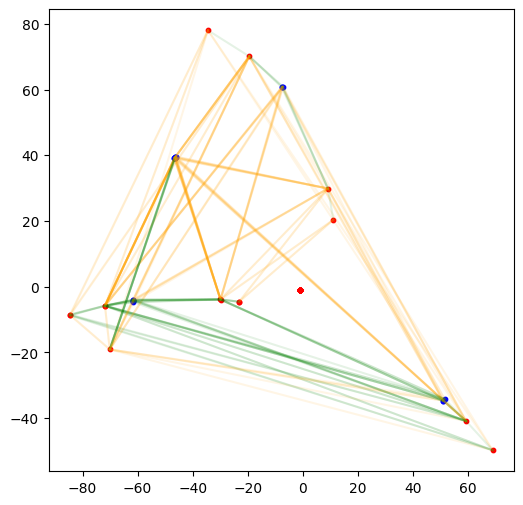

In [2]:
event_id = 1
graphs_bg = full_event_to_graphs(sig_mppc_spacetime[event_id:event_id+1], sig_pixel_spacetime[event_id:event_id+1], connect_layers=True)
fig, ax = plt.subplots(1, figsize=(6, 6))
mppc_nodes = graphs_bg[0].x[graphs_bg[0].x[:, 3] == 0]
pixel_nodes = graphs_bg[0].x[graphs_bg[0].x[:, 3] == 1]
ax.scatter(mppc_nodes[:, 0], mppc_nodes[:, 1], c='blue', s=10, label='MPPC hits')
ax.scatter(pixel_nodes[:, 0], pixel_nodes[:, 1], c='red', s=10, label='Pixel hits')
for edge_index in range(graphs_bg[0].edge_index.shape[1]):
    edge = graphs_bg[0].edge_index[:, edge_index]
    if graphs_bg[0].edge_labels[edge_index] == 1:
        color = "green"
    else:
        color = "orange"
    ax.plot(
        [graphs_bg[0].x[edge[0], 0], graphs_bg[0].x[edge[1], 0]],
        [graphs_bg[0].x[edge[0], 1], graphs_bg[0].x[edge[1], 1]],
        c=color,
        alpha=0.1,
    )
print(f"Event has {(graphs_bg[0].x[:, 3] == 0).sum()} MPPC hits and {(graphs_bg[0].x[:, 3] == 1).sum()} Pixel hits")

In [ ]:
graphs_bg[0].x

tensor([[  -1.0000,   -1.0000,   -1.0000,    1.0000,    0.0000],
        [  -1.0000,   -1.0000,   -1.0000,    1.0000,    0.0000],
        [  -1.0000,   -1.0000,   -1.0000,    1.0000,    0.0000],
        [  -1.0000,   -1.0000,   -1.0000,    1.0000,    0.0000],
        [ -19.3979,   70.0927,  -46.3200,    1.0000,    0.0000],
        [  -1.0000,   -1.0000,   -1.0000,    1.0000,    0.0000],
        [  -1.0000,   -1.0000,   -1.0000,    1.0000,    0.0000],
        [  -1.0000,   -1.0000,   -1.0000,    1.0000,    0.0000],
        [  -1.0000,   -1.0000,   -1.0000,    1.0000,    0.0000],
        [  -1.0000,   -1.0000,   -1.0000,    1.0000,    0.0000],
        [  -1.0000,   -1.0000,   -1.0000,    1.0000,    0.0000],
        [  -1.0000,   -1.0000,   -1.0000,    1.0000,    0.0000],
        [ -71.8888,   -5.7556,  -58.7000,    1.0000,    0.0000],
        [ -84.5796,   -8.7278,  -58.0300,    1.0000,    0.0000],
        [  59.4320,  -40.8607,  -61.4200,    1.0000,    0.0000],
        [  -1.0000,   -1.

: 